# ¿El café es malo para la productividad? Un caso didáctico de inferencia causal

Este notebook retoma el ejemplo del café de `clase1.md` y el DAG causal construido en `clase2.md` para mostrar, con datos reales, un punto central de la inferencia causal:

> **Estimar un efecto causal no es "correr una regresión con todas las variables que tengas". Es usar un modelo causal (un DAG) para decidir qué variables hay que controlar y cuáles hay que dejar afuera.**

Vamos a recorrer tres momentos:

1. Un análisis **ingenuo** (asociación pura) que concluye, con total confianza estadística, que el café perjudica la productividad.
2. Un análisis que usa el **DAG causal** para identificar el verdadero confusor (`Turno`) y corregir la estimación.
3. Un análisis que comete un error distinto pero igual de común: controlar por una variable que **no hay que controlar** (`Horas`, un *collider*), lo que rompe de nuevo la identificabilidad del efecto.

### Las variables

- `Y` = Productividad (`prod`), la respuesta de interés.
- `T` = Tratamiento, tomar o no café (`cafe`).
- `X1` = Turno de trabajo, día o noche (`noche`).
- `X2` = Horas trabajadas (`horas`).

Los datos son observacionales (no experimentales): nadie asignó el café al azar, cada persona decidió si tomarlo o no. Ese es justamente el problema.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from scipy import stats

pd.set_option('display.float_format', lambda x: f'{x:,.3f}')
plt.rcParams['figure.dpi'] = 110

## 1. Los datos

In [2]:
df = pd.read_csv('../clase1/datos_productividad_n_500.csv')

# treatment: 1 = toma cafe, 0 = no toma
df['treatment'] = (df['cafe'].str.strip() == 'Toma café').astype(int)
# night_shift: 1 = turno noche, 0 = turno dia
df['night_shift'] = (df['noche'] == 'Noche').astype(int)

df.head()

,noche,cafe,horas,prod,treatment,night_shift
0,Día,No toma,7.400,61.900,0,0
1,Día,No toma,3.900,69.300,0,0
2,Día,No toma,3.700,71.300,0,0
3,Día,No toma,8.200,52.200,0,0
4,Día,Toma café,10.000,58.600,1,0


In [3]:
df.describe(include='all')

,noche,cafe,horas,prod,treatment,night_shift
count,500,500,500.000,500.000,500.000,500.000
unique,2,2,NaN,NaN,NaN,NaN
top,Día,No toma,NaN,NaN,NaN,NaN
freq,328,272,NaN,NaN,NaN,NaN
mean,NaN,NaN,10.497,54.694,0.456,0.344
std,NaN,NaN,4.074,11.315,0.499,0.476
min,NaN,NaN,2.000,25.900,0.000,0.000
25%,NaN,NaN,7.375,46.775,0.000,0.000
50%,NaN,NaN,9.950,56.150,0.000,0.000
75%,NaN,NaN,13.300,62.825,1.000,1.000


Antes de tocar un solo modelo, miremos cómo se relacionan `turno`, `café` y `horas` entre sí. Esto va a ser la clave de todo lo que sigue:

In [4]:
print('Proporcion que toma cafe, por turno:')
print(df.groupby('noche')['treatment'].mean(), '\n')

print('Productividad promedio, por turno:')
print(df.groupby('noche')['prod'].mean(), '\n')

print('Horas promedio, por turno y por cafe:')
print(df.groupby(['noche', 'cafe'])['horas'].mean())

Proporcion que toma cafe, por turno:
noche
Día     0.293
Noche   0.767
Name: treatment, dtype: float64 

Productividad promedio, por turno:
noche
Día     60.563
Noche   43.501
Name: prod, dtype: float64 

Horas promedio, por turno y por cafe:
noche  cafe     
Día    No toma      7.860
       Toma café    9.728
Noche  No toma     12.650
       Toma café   15.038
Name: horas, dtype: float64


El patrón ya es sospechoso: en el turno noche se toma más café **y** la productividad promedio es más baja. Si no separamos estos dos efectos, vamos a terminar confundiéndolos.

## 2. La hipótesis ingenua: "el café es malo"

La forma más directa (y más tentadora) de responder "¿el café afecta la productividad?" es comparar las medias de productividad entre quienes toman café y quienes no, con un test de hipótesis:

$$H_1: \; E(Y \mid T = \text{café}) \neq E(Y \mid T = \text{no café})$$

Esto es exactamente lo que propone `clase1.md`: correr un `t.test` o, equivalentemente, un modelo lineal $Y = \beta_0 + \beta_1 \, I_T + \varepsilon$, y mirar si $\beta_1$ es significativamente distinto de cero.

In [5]:
coffee_group = df.loc[df['treatment'] == 1, 'prod']
no_coffee_group = df.loc[df['treatment'] == 0, 'prod']

t_stat, p_value = stats.ttest_ind(coffee_group, no_coffee_group)
print(f'Media prod (toma cafe):    {coffee_group.mean():.2f}')
print(f'Media prod (no toma cafe): {no_coffee_group.mean():.2f}')
print(f't-stat = {t_stat:.3f}, p-valor = {p_value:.2e}')

Media prod (toma cafe):    50.40
Media prod (no toma cafe): 58.30
t-stat = -8.286, p-valor = 1.09e-15


In [6]:
model_naive = smf.ols('prod ~ treatment', data=df).fit()
print(model_naive.summary())

                            OLS Regression Results                            
Dep. Variable:                   prod   R-squared:                       0.121
Model:                            OLS   Adj. R-squared:                  0.119
Method:                 Least Squares   F-statistic:                     68.66
Date:                Mon, 24 Aug 2026   Prob (F-statistic):           1.09e-15
Time:                        20:27:14   Log-Likelihood:                -1889.8
No. Observations:                 500   AIC:                             3784.
Df Residuals:                     498   BIC:                             3792.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     58.2963      0.644     90.546      0.0

El resultado es contundente: $\hat{\beta}_1 \approx -7.9$, con un p-valor prácticamente nulo. Estadísticamente, tomar café está asociado a **7.9 puntos menos** de productividad.

Es tentador concluir: *"hay evidencia estadística fuerte de que el café reduce la productividad, así que hay que sacarlo"*. Este es el error que `clase1.md` marca explícitamente:

> El impacto causal y la intervención no pueden basarse en asociación, y sacar el café no garantiza que la productividad vaya a mejorar.

El problema es que $\beta_1$ mide $E(Y \mid T=1) - E(Y \mid T=0)$: una diferencia de medias **condicionada en lo que la gente ya decidió hacer**. Eso no es el ATE que realmente nos interesa:

$$\text{ATE} = E(Y^1) - E(Y^0)$$

donde $Y^1$ e $Y^0$ son los *potential outcomes*: la productividad que tendría **la misma persona** si tomara café y si no lo tomara. $E(Y \mid T=t)$ solo coincide con $E(Y^t)$ bajo supuestos muy específicos que todavía no verificamos.

## 3. Por qué la asociación no alcanza: potential outcomes

Para cada persona existen dos mundos hipotéticos: $Y^1$ (su productividad si tomara café) e $Y^0$ (si no lo tomara). Nunca observamos los dos al mismo tiempo — es el **problema fundamental de datos faltantes** de la inferencia causal: de cada individuo vemos su factual, y su contrafactual es, por diseño, missing data.

Dos supuestos hacen que el problema tenga sentido:

- **SUTVA** (*Stable Unit Treatment Value Assumption*): la respuesta de un individuo depende solo de su propio tratamiento, no del tratamiento de otros (a diferencia de, por ejemplo, la vacunación).
- **Consistencia**: lo que observamos coincide con el potential outcome correspondiente al tratamiento recibido: $T=t \Rightarrow Y = Y^t$.

Con consistencia sabemos que $E(Y \mid T=t) = E(Y^t \mid T=t)$. Pero lo que queremos es $E(Y^t)$ *sin* condicionar en $T=t$ — la productividad promedio de **toda la población** en ese mundo hipotético, no solo de quienes efectivamente eligieron ese tratamiento.

¿Cuándo $E(Y^t \mid T=t) = E(Y^t)$? Cuando $Y^t$ es **independiente** de $T$. Esto es exactamente lo que garantiza la aleatorización: si el tratamiento se asigna al azar, los grupos son intercambiables (*exchangeability*) y no hay sesgo de selección.

En nuestros datos el café **no** fue asignado al azar — cada persona decidió tomarlo o no, y esa decisión está relacionada con el turno. Sin aleatorización, $E(Y \mid T=t) \neq E(Y^t)$ en general, y el ATE **no queda identificado** solo con lo que observamos: se puede demostrar (es la tarea de `clase1.md`) que existen infinitas distribuciones contrafactuales compatibles con los mismos datos observados $(T, Y)$, cada una con un ATE distinto. Las distribuciones marginales no determinan la conjunta — el mismo argumento que la tabla de diabetes/colesterol de la práctica.

La salida no es "conseguir más datos": es traer **conocimiento de dominio**, plasmado en un DAG causal, para saber qué hace falta ajustar.

## 4. El DAG causal

`clase2.md` propone el siguiente DAG para este problema:

- `Turno → Productividad`
- `Turno → Café`
- `Café → Productividad`
- `Café → Horas`
- `Productividad → Horas`

Dibujémoslo:

```mermaid
flowchart LR
    Turno((Turno)):::confounder --> Cafe((Cafe)):::treatment
    Turno --> Prod((Productividad)):::outcome
    Cafe --> Prod
    Cafe --> Horas((Horas)):::collider
    Prod --> Horas

    classDef confounder fill:#4C956C,color:#fff,stroke:#333;
    classDef treatment fill:#1F77B4,color:#fff,stroke:#333;
    classDef outcome fill:#FF7F0E,color:#fff,stroke:#333;
    classDef collider fill:#D62728,color:#fff,stroke:#333;
```

*(Si tu visor de notebooks no renderiza Mermaid, GitHub y VS Code sí lo hacen de forma nativa sobre este mismo bloque de markdown.)*

Cada arista tiene un significado concreto:

- `Turno → Café`: el turno influye en si la persona toma café (de noche se toma más).
- `Turno → Productividad`: el turno afecta la productividad directamente (de noche se rinde menos, más allá del café).
- `Café → Productividad`: el efecto causal que realmente queremos medir.
- `Café → Horas` y `Productividad → Horas`: la cantidad de horas trabajadas es *consecuencia* tanto de haber tomado café como de qué tan productiva fue la persona (quien rinde poco, o quien tomó café, puede terminar quedándose más horas). `Horas` es un efecto **común** de `Café` y `Productividad`, no una causa de ninguna de las dos.

## 5. El criterio de backdoor: qué ajustar y qué no

Con el DAG en mano, buscamos todos los **caminos backdoor**: caminos que conectan `Café` y `Productividad` sin salir de `Café` por una flecha que sale de él hacia adelante (es decir, caminos "espurios", no el efecto causal directo).

**Camino 1 — confusión real:** `Café ← Turno → Productividad`.

Turno es una causa común de Café y de Productividad: es un **confusor**. Este camino backdoor está *abierto* y mezcla el efecto del turno con el del café en la comparación ingenua. Para cerrarlo hay que **condicionar en Turno**.

Esto es exactamente el supuesto de **conditional exchangeability** de `clase2.md`: existe una variable $X$ (acá, Turno) tal que

$$Y^{(a)} \perp T \mid X$$

y bajo ese supuesto se puede demostrar que el ATE queda identificado a partir de las variables observadas:

$$E(Y^1) - E(Y^0) = E_X\big[E(Y \mid X, T=1) - E(Y \mid X, T=0)\big]$$

**Camino 2 — un collider, no un confusor:** `Café → Horas ← Productividad`.

Horas no es causa común de nada: es un **efecto común** de Café y Productividad, un *collider*. Un camino que pasa por un collider está *cerrado por naturaleza* — no hace falta (ni conviene) hacer nada con él. Pero si **condicionamos en un collider**, el camino se **abre**, y aparece una asociación espuria entre Café y Productividad que no tiene nada que ver con causalidad. Es el mismo mecanismo que la paradoja de Berkson.

En otras palabras: agregar `Horas` a la regresión no es "controlar mejor" — es **romper** la conditional exchangeability que ya habíamos logrado con Turno.

## 6. La estimación correcta: ajustando por Turno

In [7]:
model_adjusted = smf.ols('prod ~ treatment + night_shift', data=df).fit()
print(model_adjusted.summary())

                            OLS Regression Results                            
Dep. Variable:                   prod   R-squared:                       0.515
Model:                            OLS   Adj. R-squared:                  0.513
Method:                 Least Squares   F-statistic:                     263.7
Date:                Mon, 24 Aug 2026   Prob (F-statistic):           8.95e-79
Time:                        20:27:14   Log-Likelihood:                -1741.3
No. Observations:                 500   AIC:                             3489.
Df Residuals:                     497   BIC:                             3501.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      60.7588      0.494    122.914      

Al condicionar en `Turno`, el coeficiente de `treatment` pasa de $\approx -7.9$ (altamente significativo) a $\approx -0.7$, con un p-valor que ya no permite rechazar $H_0: \beta_1 = 0$.

La conclusión cambia por completo: **no hay evidencia de que el café afecte la productividad**. Lo que la hipótesis ingenua atribuía al café era, en realidad, el efecto del turno: de noche se toma más café y, de noche, la productividad es más baja por otras razones — pero eso no es culpa del café.

## 7. El error simétrico: controlar por un collider

Ahora cometamos, a propósito, el error de "cuantas más variables mejor" y agreguemos `Horas` al modelo, además de `Turno`:

In [8]:
model_collider = smf.ols('prod ~ treatment + night_shift + horas', data=df).fit()
print(model_collider.summary())

                            OLS Regression Results                            
Dep. Variable:                   prod   R-squared:                       0.855
Model:                            OLS   Adj. R-squared:                  0.854
Method:                 Least Squares   F-statistic:                     973.4
Date:                Mon, 24 Aug 2026   Prob (F-statistic):          2.36e-207
Time:                        20:27:14   Log-Likelihood:                -1439.6
No. Observations:                 500   AIC:                             2887.
Df Residuals:                     496   BIC:                             2904.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      79.6670      0.617    129.059      

El coeficiente de `treatment` no solo deja de ser cero: **cambia de signo** y vuelve a ser significativo ($\approx +4.2$). Ya habíamos cerrado el único camino backdoor real (vía Turno); lo que produjo este nuevo resultado fue abrir el camino `Café → Horas ← Productividad` al condicionar en el collider.

El resultado es tan artificial como el de la Sección 2 — solo que en la dirección opuesta. Ninguno de los dos números tiene interpretación causal salvo el de la Sección 6.

Veamos qué pasa si, además, controlamos por Horas pero *sin* controlar por Turno (el error más común: ajustar por lo primero que se nos ocurre, sin mirar el DAG):

In [9]:
model_hours_only = smf.ols('prod ~ treatment + horas', data=df).fit()
print(model_hours_only.summary())

                            OLS Regression Results                            
Dep. Variable:                   prod   R-squared:                       0.838
Model:                            OLS   Adj. R-squared:                  0.838
Method:                 Least Squares   F-statistic:                     1289.
Date:                Mon, 24 Aug 2026   Prob (F-statistic):          2.11e-197
Time:                        20:27:14   Log-Likelihood:                -1466.4
No. Observations:                 500   AIC:                             2939.
Df Residuals:                     497   BIC:                             2952.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     81.8611      0.573    142.891      0.0

## 8. Comparación final

In [10]:
comparison = pd.DataFrame({
    'modelo': [
        '1. Naive (sin ajuste)',
        '2. + Turno (backdoor cerrado)',
        '3. + Turno + Horas (collider abierto)',
        '4. Solo Horas, sin Turno',
    ],
    'variables_de_ajuste': ['ninguna', 'turno', 'turno + horas', 'horas'],
    'coef_cafe': [
        model_naive.params['treatment'],
        model_adjusted.params['treatment'],
        model_collider.params['treatment'],
        model_hours_only.params['treatment'],
    ],
    'p_valor': [
        model_naive.pvalues['treatment'],
        model_adjusted.pvalues['treatment'],
        model_collider.pvalues['treatment'],
        model_hours_only.pvalues['treatment'],
    ],
})
comparison

,modelo,variables_de_ajuste,coef_cafe,p_valor
0,1. Naive (sin ajuste),ninguna,-7.900,0.000
1,2. + Turno (backdoor cerrado),turno,-0.668,0.401
2,3. + Turno + Horas (collider abierto),turno + horas,4.244,0.000
3,"4. Solo Horas, sin Turno",horas,3.759,0.000


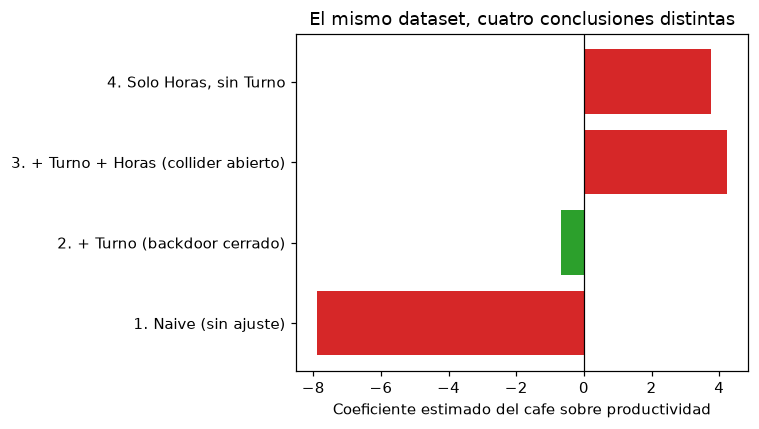

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#D62728', '#2CA02C', '#D62728', '#D62728']
ax.barh(comparison['modelo'], comparison['coef_cafe'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coeficiente estimado del cafe sobre productividad')
ax.set_title('El mismo dataset, cuatro conclusiones distintas')
plt.tight_layout()
plt.show()

## 9. Conclusión

Con exactamente los mismos datos, cuatro decisiones distintas sobre qué ajustar producen cuatro conclusiones distintas — dos de ellas apuntando en direcciones opuestas y solo una con derecho a interpretación causal:

1. **Sin ajustar nada**: el café parece pésimo. Falso — es confusión por turno.
2. **Ajustando por el confusor (Turno)**: el efecto desaparece. Esta es la estimación consistente con el ATE, porque cierra el único camino backdoor y respeta la conditional exchangeability del DAG.
3. **Ajustando además por el collider (Horas)**: el efecto reaparece con signo contrario. Es tan espurio como el punto 1, producido por abrir un camino que estaba cerrado.
4. **Ajustando solo por Horas**: mismo problema, sin siquiera haber cerrado el backdoor real.

La lección no es "ajustar por más variables es más riguroso" ni "ajustar por menos es más seguro": es que **la decisión de qué incluir en el modelo la toma el DAG, no la disponibilidad de columnas en el dataset**. Sin un modelo causal explícito, un análisis de regresión —por más significativo que sea el p-valor— no permite distinguir entre estos cuatro escenarios.

## 10. Bootstrap: un intervalo de confianza para el ATE

Nos quedamos con `model_adjusted` (Sección 6) como la única estimación con derecho a interpretación causal: cierra el backdoor real (`Turno`) y no toca el collider (`Horas`). Pero hasta acá solo miramos el error estándar y el p-valor que `statsmodels` calcula bajo el supuesto de que los residuos son homocedásticos y (asintóticamente) normales. Queremos una segunda forma de cuantificar la incertidumbre del ATE, que no dependa de esos supuestos: **bootstrap de casos**.

La idea es simple: si no conocemos la distribución poblacional de $(T, X_1, Y)$, la aproximamos con la única muestra que tenemos, tratando a nuestros 500 casos como si fueran la población. Repetimos muchas veces el siguiente experimento:

1. Remuestrear con reemplazo $n=500$ filas del propio dataset.
2. Reajustar `model_adjusted` (`prod ~ treatment + night_shift`) sobre esa réplica.
3. Guardar el coeficiente estimado $\hat\beta_{\text{treatment}}$ de esa réplica.

Con $B$ réplicas obtenemos una distribución empírica de $\hat\beta_{\text{treatment}}$, y de ahí construimos un intervalo de confianza al 95% tomando los percentiles 2.5% y 97.5% de esa distribución.

La garantía que da este intervalo es puramente frecuentista, y vale la pena decirla con precisión para no confundirla con un intervalo de credibilidad bayesiano (como el HDI del notebook `analisis_causal_cafe_bayesiano.ipynb`): *si repitiéramos el estudio (recolectar 500 casos nuevos y aplicar este mismo procedimiento de bootstrap) muchísimas veces, el 95% de los intervalos que construyamos de esta manera contendrían el verdadero ATE*. No es una afirmación de probabilidad sobre el parámetro en este estudio particular — es sobre el procedimiento a largo plazo.

El criterio que nos interesa es directo: **si el 0 cae dentro del intervalo, no tenemos evidencia estadística de que el café tenga un efecto causal sobre la productividad** (ni positivo ni negativo), lo cual sería consistente con el p-valor no significativo que ya vimos en la Sección 6.

In [12]:
RANDOM_SEED = 42
n_boot = 2000

rng = np.random.default_rng(RANDOM_SEED)
boot_estimates = np.empty(n_boot)

for i in range(n_boot):
    df_boot = df.sample(n=len(df), replace=True, random_state=rng.integers(1_000_000))
    model_boot = smf.ols('prod ~ treatment + night_shift', data=df_boot).fit()
    boot_estimates[i] = model_boot.params['treatment']

ci_lower, ci_upper = np.percentile(boot_estimates, [2.5, 97.5])
contains_zero = ci_lower <= 0 <= ci_upper

print(f'Coeficiente observado (muestra original):  {model_adjusted.params["treatment"]:.3f}')
print(f'Media de las {n_boot} replicas bootstrap:     {boot_estimates.mean():.3f}')
print(f'Desvio estandar bootstrap:                  {boot_estimates.std():.3f}')
print(f'Intervalo de confianza bootstrap (95%):     [{ci_lower:.3f}, {ci_upper:.3f}]')
print(f'¿El intervalo contiene al 0?                 {contains_zero}')

Coeficiente observado (muestra original):  -0.668
Media de las 2000 replicas bootstrap:     -0.667
Desvio estandar bootstrap:                  0.761
Intervalo de confianza bootstrap (95%):     [-2.180, 0.809]
¿El intervalo contiene al 0?                 True


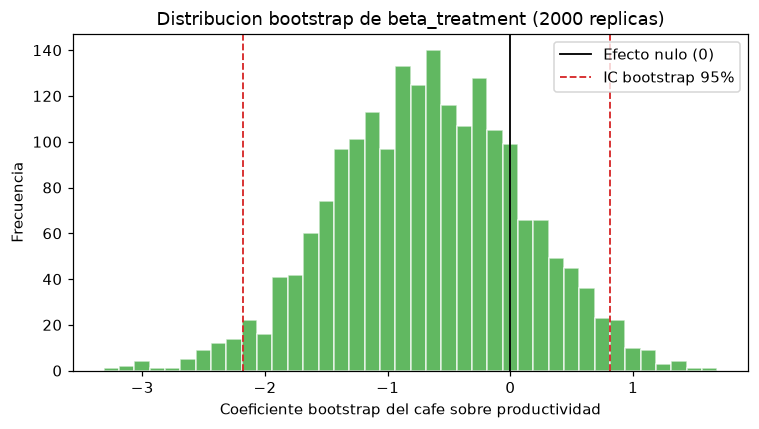

In [13]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(boot_estimates, bins=40, color='#2CA02C', alpha=0.75, edgecolor='white')
ax.axvline(0, color='black', linewidth=1.2, linestyle='-', label='Efecto nulo (0)')
ax.axvline(ci_lower, color='#D62728', linewidth=1.2, linestyle='--', label='IC bootstrap 95%')
ax.axvline(ci_upper, color='#D62728', linewidth=1.2, linestyle='--')
ax.set_xlabel('Coeficiente bootstrap del cafe sobre productividad')
ax.set_ylabel('Frecuencia')
ax.set_title(f'Distribucion bootstrap de beta_treatment ({n_boot} replicas)')
ax.legend()
plt.tight_layout()
plt.show()

El intervalo de confianza bootstrap contiene al 0, tal como anticipaba el p-valor no significativo de la Sección 6 ($p=0.401$). Esto le da una segunda pata a la misma conclusión: **no hay evidencia estadística de que el café afecte la productividad**, una vez cerrado el backdoor por Turno. Y esta vez la conclusión no depende de que los residuos de `model_adjusted` sean normales ni de que su varianza sea constante — el bootstrap solo necesita que la muestra sea representativa, y remuestrea directamente sobre los datos para estimar la variabilidad del coeficiente.

Vale la pena remarcar qué es lo que el bootstrap **no** hace: no cambia qué variables hay que ajustar. Eso lo sigue decidiendo el DAG, no el procedimiento de inferencia. Si hubiéramos bootstrapeado `model_collider` (el que ajusta por el collider `Horas`), habríamos obtenido un intervalo de confianza muy angosto y lejos del cero — pero igual de espurio que su estimación puntual, porque el problema ahí no es de incertidumbre estadística sino de identificación causal mal planteada.

Comparado con el notebook bayesiano: llegamos al mismo lugar por dos caminos distintos. El HDI al 89% de `beta_cafe` también incluía al cero, y ahí la lectura era una probabilidad posterior directa sobre el parámetro (*"81% de probabilidad de que el efecto sea negativo, pero un tamaño de efecto chico"*). Acá, el intervalo de confianza al 95% no admite esa lectura probabilística sobre el parámetro — solo nos dice que el procedimiento de estimación, aplicado muchas veces, capturaría al verdadero ATE con esa frecuencia. Confianza y credibilidad son lenguajes distintos para cuantificar la incertidumbre, pero en este caso — con un DAG bien especificado — los dos coinciden en la misma conclusión sustantiva.